<a href="https://colab.research.google.com/github/audomsak-pypy/Project1-Text_Analytics69/blob/main/Part_1_673020272_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Text Analytics for Business Insight(Part1) โดย นายเยี่ยมภพ ใบโพธิ์ 673020272-8
### SC 663 402 Data Warehouse and Big Data Analytics

**กำหนดส่ง:** อังคาร 6 ตุลาคม 2569 \
**นำเสนอในชั้นเรียน:** พุธ 7 ตุลาคม 2569 (ทีมละ 10 นาที + Q&A)

## โครงสร้างงานและการส่งงาน

งานนี้แบ่งเป็น **งานเดี่ยว 1 ส่วน** และ **งานกลุ่ม 2 ส่วน**

### งานเดี่ยว — Part 1 (10 คะแนน)
* **นักศึกษาทุกคนต้องทำ Part 1 ด้วยตนเองและส่งของตนเองทุกคน**
* ให้ส่ง Notebook ของตนเองพร้อมผลรันครบ ไม่ใช่ใช้ไฟล์เดียวกันทั้งกลุ่ม
* สามารถพูดคุยแนวคิดหรือช่วยกันแก้ปัญหาทั่วไปได้ แต่โค้ด ผลวิเคราะห์ และคำตอบที่ส่งต้องเป็นงานของตนเอง
* Part 1 **ไม่ต้องนำเสนอหน้าชั้นเรียน**



In [2]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [ ]:
# ----------------- Your code here -----------------

In [8]:
import json
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# แก้ไขบรรทัดนี้: เพิ่ม drive/ นำหน้า MyDrive
path = 'drive/MyDrive'

file_names = [
    'posts_20241127_134301.jsonl',
]


# ฟังก์ชัน Generator
def iter_jsonl(file_path):
  with open(file_path, encoding='utf-8') as f:
    for line in f:
      yield json.loads(line)


# วนลูปอ่านไฟล์ด้วย Generator
data_list = []
for file in file_names:
  file_path = os.path.join(path, file)
  for record in iter_jsonl(file_path):
    data_list.append(record)

# แปลงเป็น DataFrame
data_bluesky = pd.DataFrame(data_list)
print(f'อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: {len(data_bluesky):,} รายการ')
data_bluesky

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: 100,000 รายการ


,text,created_at,author,uri,has_images,reply_to
0,,2024-11-27T13:42:59.652Z,did:plc:zotcosul2z2bhjkhmlv6iyfm,at://did:plc:zotcosul2z2bhjkhmlv6iyfm/app.bsky...,False,at://did:plc:unihmij7565agtvvpjerrzme/app.bsky...
1,The most impressive thing I ever read was one ...,2024-11-27T13:43:00.028Z,did:plc:kwx3ire724uo7olgyjdohmbg,at://did:plc:kwx3ire724uo7olgyjdohmbg/app.bsky...,False,at://did:plc:v23ee3xry3x54ht7a7boio7n/app.bsky...
2,The Economist : кількість загиблих українських...,2024-11-27T13:42:59.394Z,did:plc:sfd6k7tulepbgcawcblmfaat,at://did:plc:sfd6k7tulepbgcawcblmfaat/app.bsky...,False,None
3,*places a very obvious trap but with cheesesti...,2024-11-27T13:42:56.938Z,did:plc:gtov4jvyggaf4laqh23egzto,at://did:plc:gtov4jvyggaf4laqh23egzto/app.bsky...,True,at://did:plc:gco6ug5nf6gxer7fspkqvs3x/app.bsky...
4,ありがとう✌️\nずっと言ってくれてるよね…！！あの時よりずっとパワーアップしてると思うから...,2024-11-27T13:43:00.553Z,did:plc:te4fhx77zxkmsmdirk6ye3i6,at://did:plc:te4fhx77zxkmsmdirk6ye3i6/app.bsky...,False,at://did:plc:vnwa2b2rza5czz4a25lkjv6y/app.bsky...
...,...,...,...,...,...,...
99995,Mornin,2024-11-27T14:00:38.404Z,did:plc:ortrrmj7ycrnkawtbrun4njs,at://did:plc:ortrrmj7ycrnkawtbrun4njs/app.bsky...,False,at://did:plc:a7wa2vfaik6rgdsry67zlskm/app.bsky...
99996,Trump understands that tariffs are a way to hu...,2024-11-27T14:00:39.674Z,did:plc:o3o4uv5qav4zqvstn4rov27e,at://did:plc:o3o4uv5qav4zqvstn4rov27e/app.bsky...,False,None
99997,When people who should be evacuated are not. #...,2011-03-20T02:54:08Z,did:plc:yzaswzphpzrz6mt3assln46u,at://did:plc:yzaswzphpzrz6mt3assln46u/app.bsky...,False,None
99998,i MUST get tickets!,2024-11-27T14:00:38.477Z,did:plc:fofb3m5koxhs6737fmzeqnwz,at://did:plc:fofb3m5koxhs6737fmzeqnwz/app.bsky...,False,at://did:plc:ulwib66l6dqsiclybq5s6oox/app.bsky...


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# แปลงคอลัมน์ created_at ให้เป็น datetime โดยระบุ format='ISO8601'
data_bluesky['created_at_dt'] = pd.to_datetime(data_bluesky['created_at'], format='ISO8601')

/tmp/ipykernel_1801/1977724701.py:7: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_bluesky['created_at_dt'] = pd.to_datetime(data_bluesky['created_at'], format='ISO8601')


In [20]:
!pip install -q langdetect

# **1. คนโพสต์เมื่อไร**
- เพื่อบอกจำนวนโพสต์ทั้งหมด , ช่วงเวลาที่ข้อมูลครอบคลุม , ชั่วโมงที่โพสต์มากที่สุด

In [14]:
# 1. คนโพสต์เมื่อไร
# แปลงคอลัมน์ created_at ให้เป็น datetime แบบกำหนด utc=True เพื่อรองรับ timezone ที่หลากหลาย
data_bluesky['created_at_dt'] = pd.to_datetime(data_bluesky['created_at'], format='ISO8601', utc=True)

total_posts = len(data_bluesky)
min_time = data_bluesky['created_at_dt'].min()
max_time = data_bluesky['created_at_dt'].max()

# หาชั่วโมงที่โพสต์มากที่สุด (UTC)
data_bluesky['hour'] = data_bluesky['created_at_dt'].dt.hour
peak_hour = data_bluesky['hour'].mode()[0]
peak_hour_count = (data_bluesky['hour'] == peak_hour).sum()

print("=== 1. คนโพสต์เมื่อไร ===")
print(f"จำนวนโพสต์ทั้งหมด: {total_posts:,} รายการ")
print(f"ช่วงเวลาที่ข้อมูลครอบคลุม: ตั้งแต่ {min_time} ถึง {max_time}")
print(f"ชั่วโมงที่มีการโพสต์มากที่สุด: {peak_hour:02d}:00 น. (UTC) จำนวน {peak_hour_count:,} โพสต์\n")

=== 1. คนโพสต์เมื่อไร ===
จำนวนโพสต์ทั้งหมด: 100,000 รายการ
ช่วงเวลาที่ข้อมูลครอบคลุม: ตั้งแต่ 2008-10-15 07:27:37+00:00 ถึง 2024-11-28 13:58:59.018000+00:00
ชั่วโมงที่มีการโพสต์มากที่สุด: 13:00 น. (UTC) จำนวน 89,657 โพสต์



# **2. ใช้ภาษาอะไร**
- ภาษาอังกฤษเป็นภาษาหลัก (มีภาษาญี่ปุ่น และภาษารัสเซีย/ยูเครน ปะปนอยู่)

In [19]:
# 2. ใช้ภาษาอะไร? (ตรวจจับภาษาเบื้องต้นด้วย langdetect หรือ fasttext)
from langdetect import detect

def detect_lang_safe(text):
    try:
        return detect(str(text))
    except:
        return 'unknown'

# สุ่มตรวจสับเซตเพื่อความเร็ว หรือรันทั้งหมดหากมีเวลา
sample_df = data_bluesky.sample(n=min(5000, len(data_bluesky)), random_state=42)
sample_df['lang'] = sample_df['text'].apply(detect_lang_safe)

lang_counts = sample_df['lang'].value_counts(normalize=True) * 100

print("=== 2. ใช้ภาษาอะไร ===")
print("สัดส่วนภาษาหลัก (สุ่มตรวจ 5,000 ตัวอย่าง):")
print(lang_counts.head(5).to_string())
print("\nคำแนะนำ: หากทำคอนเทนต์ควรใช้อันดับ 1 และ 2 เพื่อรองรับผู้ใช้ส่วนใหญ่\n")

=== 2. ใช้ภาษาอะไร ===
สัดส่วนภาษาหลัก (สุ่มตรวจ 5,000 ตัวอย่าง):
lang
en         53.28
ja         12.14
unknown     6.68
pt          4.18
es          4.00

คำแนะนำ: หากทำคอนเทนต์ควรใช้อันดับ 1 และ 2 เพื่อรองรับผู้ใช้ส่วนใหญ่



# **3. คนพูดถึงอะไร**
- มีการพูดถึงประเด็นข่าวสารการเมือง (เช่น Trump), ข่าวเศรษฐกิจ/สงคราม (เช่น The Economist), ความคิดเห็นส่วนตัว, และข้อความภาษาญี่ปุ่น
- **ตัวอย่าง** เช่น Trump understands that tariffs are a way to hu... , The Economist : кількість загиблих українських... , The most impressive thing I ever read was one ...

In [21]:
# 3. คนพูดถึงอะไร? (หา Hashtag และคำ/วลีเด่น)
all_hashtags = []
for text in data_bluesky['text'].dropna():
    hashtags = re.findall(r'#\w+', str(text).lower())
    all_hashtags.extend(hashtags)

top_hashtags = Counter(all_hashtags).most_common(5)

print("=== 3. คนพูดถึงอะไร ===")
print("Hashtag เด่นที่ถูกกล่าวถึงบ่อยที่สุด:")
for tag, count in top_hashtags:
    print(f"- {tag}: {count:,} ครั้ง")

# ตัวอย่างข้อความจริงประกอบ
print("\nตัวอย่างข้อความจริงประกอบ:")
for i, sample_text in enumerate(data_bluesky['text'].dropna().sample(3, random_state=42), 1):
    print(f"{i}. \"{sample_text}\"")
print("\n")

=== 3. คนพูดถึงอะไร ===
Hashtag เด่นที่ถูกกล่าวถึงบ่อยที่สุด:
- #art: 262 ครั้ง
- #eduinov: 222 ครั้ง
- #booksky: 182 ครั้ง
- #bettencourt: 167 ครั้ง
- #photography: 142 ครั้ง

ตัวอย่างข้อความจริงประกอบ:
1. "I wonder how that new Silent Hill movie is coming along."
2. ""
3. "Lonely road of faith"




# **4. ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้**
- แสดงการแจกแจงจำนวนโพสต์ตามชั่วโมง (ตามโค้ดด้านบน)
- **ข้อจำกัดของข้อมูล (3–5 บรรทัด)**
  - ข้อมูลนี้เป็นเพียงสแนปชอตช่วงเวลาสั้นๆ (ส่วนใหญ่กระจุกตัวอยู่ภายในเวลาไม่กี่ชั่วโมงของวันที่ 27 พ.ย. 2024) จึงไม่สามารถสะท้อนพฤติกรรมในระยะยาวได้ , ข้อมูลถูกจำกัดอยู่ที่ 100,000 โพสต์แรกจาก API ไม่ได้ครอบคลุมผู้ใช้ Bluesky ทั้งหมดในระบบ , ข้อมูลขาด Demographic data เช่น อายุ เพศ หรือประเทศของผู้ใช้ ทำให้ไม่สามารถวิเคราะห์พฤติกรรมเชิงลึกตามพื้นที่ได้ , มี Outlier ของช่วงเวลา (เช่น ปี 2011) ซึ่งเกิดจากข้อมูลผิดพลาดในระบบส่งผลให้การวิเคราะห์เวลาคลาดเคลื่อนได้

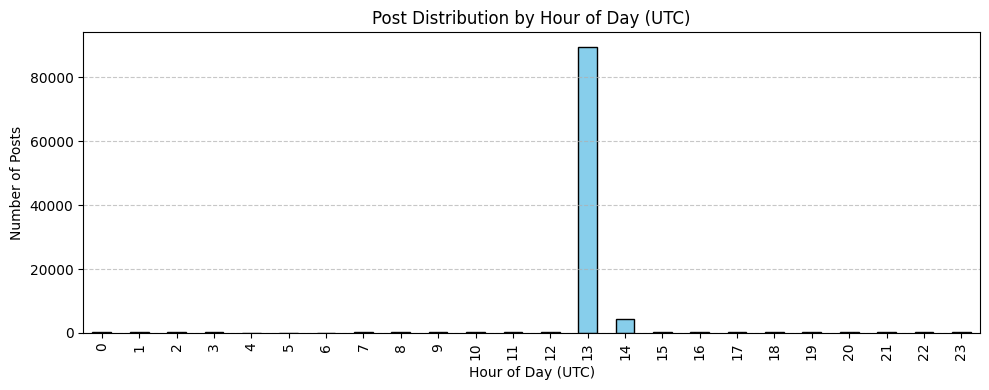

In [22]:
# 4. ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้? (สร้าง Visualization 1 รูป)
plt.figure(figsize=(10, 4))
data_bluesky['hour'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Post Distribution by Hour of Day (UTC)')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Posts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**

* ...